In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

In [22]:
df=pd.read_csv("corpus_zola_paquets_lemm.csv") # Chargement du DataFrame nettoyé à partir du fichier CSV

In [23]:
df.head()

,nom_fichier,id_paquet,phrases_paquet,phrases_lemm
0,1893_20_Le_docteur_Pascal._clean.txt,0,Dans la chaleur de l’ardente après-midi de jui...,chaleur ardent après-midi juillet salle volet ...
1,1893_20_Le_docteur_Pascal._clean.txt,1,La défense d’y entrer était formelle. C’était ...,défense formel préparation spécial suite bruit...
2,1893_20_Le_docteur_Pascal._clean.txt,2,"Directeur de l’Époque, répéta-t-elle, c’est un...",directeur époque vrai situation ministre père ...
3,1893_20_Le_docteur_Pascal._clean.txt,3,"Tiens! grand-mère, les dossiers sont là-haut. ...",grand-mère dossier haut parole porte chambre o...
4,1893_20_Le_docteur_Pascal._clean.txt,4,"Jamais elle n’entrait dans cette chambre, où i...",chambre travail close tabernacle anxiété prise...


In [34]:
vectorizer = TfidfVectorizer( 
    min_df=3,
    max_df=0.8
    )
# min_df=5 : Ignorer les termes qui apparaissent dans moins de 3 segments, car ils sont considérés comme peu informatifs.
# max_df=0.8 : Ignorer les termes qui apparaissent dans plus de 80% des segments, car ils sont trop fréquents et ne contribuent pas à différencier les segments.

X = vectorizer.fit_transform(df["phrases_lemm"])  
#Appliquer le TF-IDF vectorizer sur les segments de texte nettoyés pour obtenir une matrice de caractéristiques (termes pondérés par leur importance dans les segments).

X.shape

(2141, 11580)

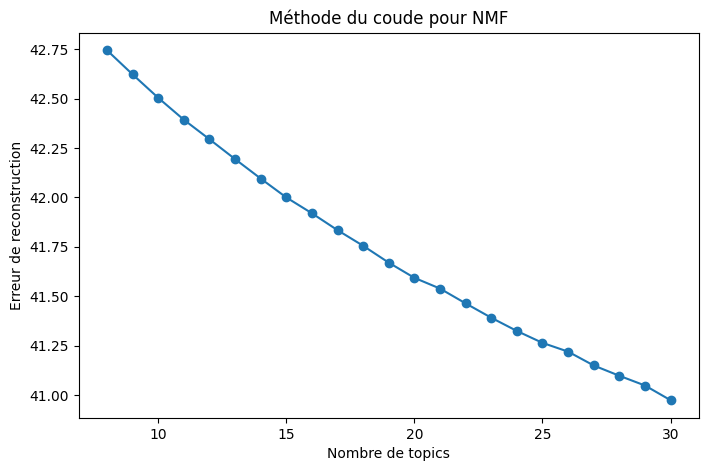

In [35]:
errors = []
k_values = range(8, 31)

for k in k_values:
    nmf = NMF(
        n_components=k,
        random_state=42,
        init="nndsvda",
        max_iter=500
    )
    
    nmf.fit(X)
    errors.append(nmf.reconstruction_err_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, errors, marker="o")
plt.xlabel("Nombre de topics")
plt.ylabel("Erreur de reconstruction")
plt.title("Méthode du coude pour NMF")
plt.show()

In [36]:
def afficher_topics(model, feature_names, n_top_words=8):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx+1} : {' | '.join(top_words)}")



feature_names = vectorizer.get_feature_names_out()

#for k in  [8, 10, 12, 15, 18 ]: # On teste différents nombres de topics (de 5 à 15) pour trouver le nombre optimal de topics pour notre analyse.
    
    #print(f"\n NMF avec {k} topics") 
nmf = NMF(n_components=14, 
          random_state=42,
          init="nndsvda",
          solver="cd",
          max_iter=500,
          
            )
W = nmf.fit_transform(X)
afficher_topics(nmf, feature_names)

print("Erreur :", nmf.reconstruction_err_)

Topic 1 : docteur | malade | grotte | sœur | saint | médecin | miracle | train
Topic 2 : enfant | travail | vie | usine | mère | fils | œuvre | fille
Topic 3 : soleil | arbre | herbe | eau | ciel | rose | blanc | jardin
Topic 4 : abbé | prêtre | curé | église | trouche | monsieur | jardin | soutane
Topic 5 : félicité | insurgé | ville | rue | barricade | national | républicain | fusil
Topic 6 : monsieur | dame | salon | comte | comtesse | porte | empereur | deberl
Topic 7 : prussien | soldat | armée | général | route | cheval | canon | empereur
Topic 8 : jeune | chambre | amour | cœur | amant | pensée | nuit | lit
Topic 9 : coupeau | rue | boutique | maman | vin | zingueur | verre | blanchisseur
Topic 10 : école | instituteur | frère | père | élève | modèle | vérité | église
Topic 11 : fosse | maheude | coron | mineur | camarade | ouvrier | berline | puits
Topic 12 : vendeur | rayon | magasin | comptoir | dame | soie | client | rue
Topic 13 : franc | argent | affaire | bourse | million